<div style="background-color:#d7c6f3; padding: 18px; border-radius: 3px; text-align:center; font-size:2.5em; font-weight:bold; color:#222; margin-bottom:25px; letter-spacing:1px;">
Predicting Donor Response for Social Good 
</div>

# <h2 style="border-bottom: 4px solid #b79ad6; width:fit-content; margin: 0 auto 25px auto; padding-bottom:6px; font-weight:bold;">Feature Engineering</h2>

_Data Mining II 2025/2026_

Project by:
Francisco Gomes (20221810), Margarida Marchão (20221901), Marta Alves (20221890), Pedro Coimbras (20211573)


## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">1. Imports and data loading</h3>

This notebook extends the baseline workflow by creating new donor-level features from the original variables. The main objective is to verify whether engineered features improve the predictive signal identified in the previous notebook.


In [1]:
"""Importing the libraries needed for feature engineering, preprocessing, modeling, and evaluation"""
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

"""Adding the project root to the Python path so notebook imports work correctly"""
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


In [2]:
"""Loading the training dataset for feature-engineering experiments"""
data = pd.read_csv(PROJECT_ROOT / "project_data" / "donors_train.csv", index_col=0)
data.head()


,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
61745,4.0,3.0,33.0,M,0.0,1.0,H,5.0,20.0,9.0,35.0,2.0,20.0,15.0,21.0,566.0,315.0,182.037132,18.0,18.0,10.0,0.0,52.0,17.0,25.0,92.0,0.0,12827.0,A,0.00,17.50,NaN,0.000,2.0,0.154,0.0,2,T,NaN,1
112703,3.0,2.0,NaN,F,1.0,1.0,U,NaN,15.0,6.0,15.0,1.0,15.0,15.0,15.0,318.0,148.0,24.000000,24.0,24.0,7.0,0.0,31.0,31.0,39.0,73.0,0.0,7787.0,N,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1
166437,4.0,2.0,NaN,F,7.0,3.0,H,4.0,10.0,17.0,79.0,11.0,12.0,5.0,40.0,1669.0,373.0,129.000000,15.0,15.0,8.0,0.0,26.0,39.0,38.0,84.0,1.0,13965.0,S,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0
170621,4.0,NaN,61.0,M,13.0,1.0,H,6.0,11.0,28.0,80.0,17.0,11.0,3.0,75.0,1464.0,488.0,130.000000,16.0,16.0,13.0,0.0,48.0,30.0,44.0,84.0,1.0,24123.0,A,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0
44428,6.0,0.0,75.0,M,3.0,4.0,H,3.0,7.0,9.0,27.0,5.0,7.0,5.0,22.0,936.0,249.0,24.000000,17.0,17.0,13.0,0.0,52.0,NaN,66.0,90.0,1.0,15008.0,N,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0


## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">2. Problem setup and data partition</h3>

To keep the comparison consistent with the baseline notebook, the same train/validation split is preserved. This way, any performance changes can be interpreted as the effect of feature engineering rather than a different split.


In [3]:
"""Defining the target variable and creating the same train-validation split used in the baseline notebook"""
TARGET = "TARGET_B"
RANDOM_STATE = 5
TRAIN_SIZE = 0.70

X = data.drop(columns=[TARGET])
y = data[TARGET].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    train_size=TRAIN_SIZE,
    shuffle=True,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Training target rate: {y_train.mean():.3f}")
print(f"Validation target rate: {y_val.mean():.3f}")


Training set shape: (9492, 39)
Validation set shape: (4068, 39)
Training target rate: 0.250
Validation target rate: 0.250


## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">3. EDA-based cleaning</h3>

Before creating new features, the same rule-based cleaning used in the baseline notebook is applied. This ensures that engineered variables are built on top of the cleaned version of the data.


### **3.1 - Using pre-processing pipeline**

In [4]:
"""Preprocessing showcase: demonstrating the preprocessing service with one-hot encoding"""
from pipeline.preprocessing_service import preprocess_data

X_train_clean = preprocess_data(
    data_original=X_train,
    outlier_columns=None,  # Auto-detect outlier columns
    outlier_method="rescale",  # Use rescaling method for outliers
    IQR_value=1.5,  # Standard IQR multiplier for outlier detection
    encode="onehot",  # One-hot encode categorical variables (matching notebook approach),
    cols_to_drop= ["WEALTH_RATING"]
)

X_val_clean = preprocess_data(
    data_original=X_val,
    outlier_columns=None,  # Auto-detect outlier columns
    outlier_method="rescale",  # Use rescaling method for outliers
    IQR_value=1.5,  # Standard IQR multiplier for outlier detection
    encode="onehot",  # One-hot encode categorical variables (matching notebook approach),
    cols_to_drop= ["WEALTH_RATING"]
)

print(f"Original shape: {X_train.shape}")
print(f"Preprocessed shape: {X_train_clean.shape}")
print(f"\nFirst few rows of preprocessed data:")

print(f"Original shape: {X_val.shape}")
print(f"Preprocessed shape: {X_val_clean.shape}")
print(f"\nFirst few rows of preprocessed data:")


[preprocess_data] Copying input data
[preprocess_data] Forcing incoherent values to null
[preprocess_data] Building imputers for missing values
[preprocess_data] Detecting outlier columns
[preprocess_data] Handling outliers
[preprocess_data] Encoding categorical variables
[preprocess_data] Preprocessing complete
Original shape: (9492, 39)
Preprocessed shape: (9492, 56)

First few rows of preprocessed data:


,CARD_PROM_12,CHILDREN,DONOR_AGE,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,WEALTH_RATING,DONOR_GENDER_F,DONOR_GENDER_M,DONOR_GENDER_U,HOME_OWNER_H,HOME_OWNER_U,RECENCY_STATUS_96NK_A,RECENCY_STATUS_96NK_E,RECENCY_STATUS_96NK_F,RECENCY_STATUS_96NK_L,RECENCY_STATUS_96NK_N,RECENCY_STATUS_96NK_S,SES_1,SES_2,SES_3,SES_4,SES_?,URBANICITY_?,URBANICITY_C,URBANICITY_R,URBANICITY_S,URBANICITY_T,URBANICITY_U
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
117283,1.609438,1.386294,2.353853e+17,2.312394,1.0,1.907760,3.846601,2.580621,5.591941,2.977011,4.070850,3.795848,3.643068,8.160669,6.309918,4.260111,3.584913e+09,3.402534,2.497680,2.715315,9.496119e+19,3.228663,4.401989,1.811239e+41,0.0,10.169307,0.000000,2.822417,1.307040,0.000000,1.178482,0.000000,2.055337,146.51192,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
146706,1.609438,0.693147,5.540622e+34,2.493087,2.0,2.046140,3.460522,3.005947,5.610409,3.074038,3.883763,3.199324,3.955253,8.697434,6.496775,4.508856,3.269017e+06,3.258097,2.497680,2.715315,1.898046e+13,3.695008,4.018418,1.220403e+39,0.0,10.175002,2.397895,3.378183,1.546545,0.117783,1.658121,0.426523,2.055337,146.51192,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
137973,1.945910,1.098612,3.104298e+26,2.572503,3.0,1.318544,3.460522,2.845220,5.617701,3.119235,3.797886,3.199324,3.833172,7.902682,5.384495,4.354371,1.318816e+09,3.465736,2.650016,2.839627,5.184706e+21,3.896826,3.943775,1.373383e+32,1.0,9.152923,2.269028,3.238186,1.901394,0.405465,1.832491,0.223144,2.055337,146.51192,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
126500,1.945910,0.000000,5.685720e+24,2.646073,4.0,1.007219,3.460522,2.901715,5.808911,3.388756,3.797886,3.199324,3.896074,7.847968,5.129899,4.392198,3.269017e+06,3.332205,2.718282,2.715315,5.834617e+14,4.147030,4.036240,3.831008e+22,1.0,8.927845,2.251292,3.211547,2.040599,0.451712,2.420318,0.511026,2.055337,146.51192,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
18200,1.945910,0.693147,1.041376e+23,2.406816,2.0,2.167679,3.361541,2.845220,5.653387,3.119235,3.965940,3.199324,3.935913,7.975746,5.560682,4.416644,1.784823e+08,3.401197,2.842247,2.715315,1.784823e+08,3.503931,4.016851,7.694785e+23,0.0,9.430680,1.791759,3.372367,1.546545,0.154436,1.832491,0.193921,2.055337,146.51192,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### **3.2 - Hand applying transformations**

In [5]:
# """Creating a rule-based cleaning function using only the issues already justified in the EDA"""
# def apply_eda_cleaning(df: pd.DataFrame) -> pd.DataFrame:
#     """Apply only the domain rules already justified in the EDA notebook."""
#     cleaned = df.copy()

#     """Treating ambiguous categorical codes as missing values"""
#     for column in ["SES", "URBANICITY"]:
#         if column in cleaned.columns:
#             cleaned[column] = cleaned[column].replace("?", np.nan)

#     """Converting domain-invalid numeric values into missing values"""
#     if "CHILDREN" in cleaned.columns:
#         cleaned.loc[cleaned["CHILDREN"] < 0, "CHILDREN"] = np.nan

#     if "RECENT_RESPONSE_PROP" in cleaned.columns:
#         invalid_recent_response = (
#             (cleaned["RECENT_RESPONSE_PROP"] < 0)
#             | (cleaned["RECENT_RESPONSE_PROP"] > 1)
#         )
#         cleaned.loc[invalid_recent_response, "RECENT_RESPONSE_PROP"] = np.nan

#     if "RECENT_CARD_RESPONSE_PROP" in cleaned.columns:
#         invalid_recent_card_response = (
#             (cleaned["RECENT_CARD_RESPONSE_PROP"] < 0)
#             | (cleaned["RECENT_CARD_RESPONSE_PROP"] > 1)
#         )
#         cleaned.loc[invalid_recent_card_response, "RECENT_CARD_RESPONSE_PROP"] = np.nan

#     return cleaned


In [6]:
# """Applying the EDA-based cleaning rules to the training and validation partitions"""
# X_train_clean = apply_eda_cleaning(X_train)
# X_val_clean = apply_eda_cleaning(X_val)

# cleaning_summary = pd.DataFrame(
#     {
#         "invalid_children_train": [int((X_train["CHILDREN"] < 0).sum())],
#         "invalid_recent_response_prop_train": [
#             int(((X_train["RECENT_RESPONSE_PROP"] < 0) | (X_train["RECENT_RESPONSE_PROP"] > 1)).sum())
#         ],
#         "invalid_recent_card_response_prop_train": [
#             int(((X_train["RECENT_CARD_RESPONSE_PROP"] < 0) | (X_train["RECENT_CARD_RESPONSE_PROP"] > 1)).sum())
#         ],
#         "ses_question_mark_train": [int((X_train["SES"].astype(str) == "?").sum())],
#         "urbanicity_question_mark_train": [int((X_train["URBANICITY"].astype(str) == "?").sum())],
#     }
# )

# display(cleaning_summary)


,invalid_children_train,invalid_recent_response_prop_train,invalid_recent_card_response_prop_train,ses_question_mark_train,urbanicity_question_mark_train
0,48,46,51,221,223


## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">4. Shared preprocessing and evaluation helpers</h3>

The comparison between original and engineered features must use the same preprocessing logic. Since the baseline notebook now compares alternative missing-value and variable-role scenarios, the helper functions below rebuild those same scenarios here so that the feature-engineering comparison remains aligned with the updated baseline workflow.


In [ ]:
"""Building shared helper functions for preprocessing, scenario evaluation, and threshold tuning"""
HIGH_MISSING_THRESHOLD = 0.40
HIGH_MISSING_CANDIDATES = ["WEALTH_RATING"]
DEFAULT_CODED_NUMERIC_FEATURES = ["INCOME_GROUP", "WEALTH_RATING"]

PREPROCESSING_SCENARIOS = [
    {
        "scenario_name": "Drop WEALTH_RATING | INCOME_GROUP numeric",
        "drop_high_missing_features": True,
        "income_group_as_categorical": False,
    },
    {
        "scenario_name": "Keep WEALTH_RATING | INCOME_GROUP numeric",
        "drop_high_missing_features": False,
        "income_group_as_categorical": False,
    },
    {
        "scenario_name": "Drop WEALTH_RATING | INCOME_GROUP categorical",
        "drop_high_missing_features": True,
        "income_group_as_categorical": True,
    },
    {
        "scenario_name": "Keep WEALTH_RATING | INCOME_GROUP categorical",
        "drop_high_missing_features": False,
        "income_group_as_categorical": True,
    },
]


def prepare_modeling_frame(df: pd.DataFrame, income_group_as_categorical: bool = False) -> pd.DataFrame:
    """Create a modeling dataframe for one preprocessing scenario."""
    prepared = df.copy()
    prepared = prepared.replace([np.inf, -np.inf], np.nan)
    numeric_columns = prepared.select_dtypes(include=[np.number]).columns
    float32_max = np.finfo(np.float32).max
    prepared[numeric_columns] = prepared[numeric_columns].mask(prepared[numeric_columns].abs() > float32_max, np.nan)

    if income_group_as_categorical and "INCOME_GROUP" in prepared.columns:
        prepared["INCOME_GROUP"] = prepared["INCOME_GROUP"].astype("object")

    categorical_columns = prepared.select_dtypes(exclude=[np.number]).columns.tolist()
    for column in categorical_columns:
        prepared[column] = prepared[column].astype("object")
        prepared[column] = prepared[column].apply(lambda value: np.nan if pd.isna(value) else value)

    return prepared



def build_one_hot_encoder() -> OneHotEncoder:
    """Create a one-hot encoder compatible with different scikit-learn versions."""
    params = {"handle_unknown": "ignore"}
    if "sparse_output" in OneHotEncoder.__init__.__code__.co_varnames:
        params["sparse_output"] = False
    else:
        params["sparse"] = False
    return OneHotEncoder(**params)



def get_feature_groups(
    df: pd.DataFrame,
    drop_high_missing_features: bool = True,
    coded_numeric_features=None,
) -> dict:
    """Organize the variables into preprocessing groups."""
    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

    if coded_numeric_features is None:
        coded_numeric_features = DEFAULT_CODED_NUMERIC_FEATURES

    dropped_high_missing_features = []
    if drop_high_missing_features:
        dropped_high_missing_features = [
            column
            for column in HIGH_MISSING_CANDIDATES
            if column in df.columns and df[column].isna().mean() >= HIGH_MISSING_THRESHOLD
        ]

    coded_numeric_features = [
        column
        for column in coded_numeric_features
        if column in numeric_features and column not in dropped_high_missing_features
    ]

    continuous_numeric_features = [
        column
        for column in numeric_features
        if column not in coded_numeric_features + dropped_high_missing_features
    ]

    return {
        "continuous_numeric_features": continuous_numeric_features,
        "coded_numeric_features": coded_numeric_features,
        "categorical_features": categorical_features,
        "dropped_high_missing_features": dropped_high_missing_features,
    }



def build_preprocessor(
    df: pd.DataFrame,
    model_family: str = "linear",
    drop_high_missing_features: bool = True,
):
    """Create a preprocessing pipeline adapted to the feature groups and the model family."""
    groups = get_feature_groups(
        df,
        drop_high_missing_features=drop_high_missing_features,
    )
    transformers = []

    continuous_numeric_steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ]
    coded_numeric_steps = [
        ("imputer", SimpleImputer(strategy="most_frequent", add_indicator=True)),
    ]

    if model_family == "linear":
        continuous_numeric_steps.append(("scaler", RobustScaler()))
        coded_numeric_steps.append(("scaler", RobustScaler()))

    if groups["continuous_numeric_features"]:
        transformers.append(
            (
                "continuous_numeric",
                Pipeline(steps=continuous_numeric_steps),
                groups["continuous_numeric_features"],
            )
        )

    if groups["coded_numeric_features"]:
        transformers.append(
            (
                "coded_numeric",
                Pipeline(steps=coded_numeric_steps),
                groups["coded_numeric_features"],
            )
        )

    if groups["categorical_features"]:
        transformers.append(
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                        ("encoder", build_one_hot_encoder()),
                    ]
                ),
                groups["categorical_features"],
            )
        )

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    return preprocessor, groups



def compute_metrics_from_probabilities(y_true, y_proba, threshold: float = 0.50) -> dict:
    """Convert predicted probabilities into class predictions and compute standard metrics."""
    y_pred = (np.asarray(y_proba) >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }



def find_best_f1_threshold(y_true, y_proba) -> float:
    """Search for the probability threshold that maximizes the F1-score on the validation set."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    if len(thresholds) == 0:
        return 0.50

    f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
    best_index = int(np.nanargmax(f1_scores))
    return float(thresholds[best_index])



def evaluate_classifier(model_pipeline, X_train_df, X_val_df, y_train_series, y_val_series, threshold: float = 0.50):
    """Fit a pipeline on the training data and evaluate it on the validation set."""
    model_pipeline.fit(X_train_df, y_train_series)
    y_proba = model_pipeline.predict_proba(X_val_df)[:, 1]
    metrics = compute_metrics_from_probabilities(y_val_series, y_proba, threshold=threshold)
    return metrics, y_proba



def evaluate_feature_set(
    feature_set_name,
    X_train_df,
    X_val_df,
    y_train_series,
    y_val_series,
    model_configs,
    preprocessing_scenarios,
):
    """Evaluate one feature representation under all preprocessing scenarios and candidate models."""
    rows = []
    validation_probabilities = {}

    for scenario in preprocessing_scenarios:
        scenario_train = prepare_modeling_frame(
            X_train_df,
            income_group_as_categorical=scenario["income_group_as_categorical"],
        )
        scenario_val = prepare_modeling_frame(
            X_val_df,
            income_group_as_categorical=scenario["income_group_as_categorical"],
        )

        for model_name, config in model_configs.items():
            preprocessor, feature_groups = build_preprocessor(
                scenario_train,
                model_family=config["model_family"],
                drop_high_missing_features=scenario["drop_high_missing_features"],
            )

            pipeline = Pipeline(
                steps=[
                    ("preprocessor", clone(preprocessor)),
                    ("model", clone(config["estimator"])),
                ]
            )

            metrics, y_proba = evaluate_classifier(
                model_pipeline=pipeline,
                X_train_df=scenario_train,
                X_val_df=scenario_val,
                y_train_series=y_train_series,
                y_val_series=y_val_series,
                threshold=0.50,
            )

            rows.append(
                {
                    "feature_set": feature_set_name,
                    "scenario_name": scenario["scenario_name"],
                    "model": model_name,
                    "model_family": config["model_family"],
                    "income_group_role": "categorical" if scenario["income_group_as_categorical"] else "numeric",
                    "wealth_rating_strategy": "drop_if_missing_ge_40pct" if scenario["drop_high_missing_features"] else "keep_with_imputation",
                    "n_continuous_numeric_features": len(feature_groups["continuous_numeric_features"]),
                    "n_coded_numeric_features": len(feature_groups["coded_numeric_features"]),
                    "n_categorical_features": len(feature_groups["categorical_features"]),
                    "dropped_high_missing": ", ".join(feature_groups["dropped_high_missing_features"]) or "None",
                    **metrics,
                }
            )

            validation_probabilities[(feature_set_name, scenario["scenario_name"], model_name)] = y_proba

    return pd.DataFrame(rows), validation_probabilities


## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">5. Baseline reference for the selected model families</h3>

The baseline notebook suggested that `Logistic Regression` and `Gradient Boosting` were the most informative candidates for the next stage. We therefore use these two models as the reference point for measuring the impact of engineered features.


In [8]:
"""Defining the candidate models carried forward from the baseline notebook"""
candidate_models = {
    "Logistic Regression": {
        "estimator": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "model_family": "linear",
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
        "model_family": "tree",
    },
}

baseline_results, baseline_validation_probabilities = evaluate_feature_set(
    feature_set_name="Baseline",
    X_train_df=X_train_clean,
    X_val_df=X_val_clean,
    y_train_series=y_train,
    y_val_series=y_val,
    model_configs=candidate_models,
    preprocessing_scenarios=PREPROCESSING_SCENARIOS,
)

display(
    baseline_results.sort_values(["roc_auc", "f1"], ascending=False).style.format(
        {
            "threshold": "{:.2f}",
            "accuracy": "{:.3f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "roc_auc": "{:.3f}",
        }
    )
)


,feature_set,scenario_name,model,model_family,income_group_role,wealth_rating_strategy,n_continuous_numeric_features,n_coded_numeric_features,n_categorical_features,dropped_high_missing,threshold,accuracy,precision,recall,f1,roc_auc
1,Baseline,Drop WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,drop_if_missing_ge_40pct,32,1,5,WEALTH_RATING,0.50,0.751,0.531,0.042,0.078,0.602
5,Baseline,Drop WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,drop_if_missing_ge_40pct,32,1,5,WEALTH_RATING,0.50,0.751,0.531,0.042,0.078,0.602
3,Baseline,Keep WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,keep_with_imputation,32,2,5,None,0.50,0.752,0.560,0.046,0.085,0.599
7,Baseline,Keep WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,keep_with_imputation,32,2,5,None,0.50,0.752,0.560,0.046,0.085,0.599
2,Baseline,Keep WEALTH_RATING | INCOME_GROUP numeric,Logistic Regression,linear,numeric,keep_with_imputation,32,2,5,None,0.50,0.575,0.305,0.548,0.392,0.588
6,Baseline,Keep WEALTH_RATING | INCOME_GROUP categorical,Logistic Regression,linear,categorical,keep_with_imputation,32,2,5,None,0.50,0.575,0.305,0.548,0.392,0.588
0,Baseline,Drop WEALTH_RATING | INCOME_GROUP numeric,Logistic Regression,linear,numeric,drop_if_missing_ge_40pct,32,1,5,WEALTH_RATING,0.50,0.576,0.306,0.550,0.394,0.588
4,Baseline,Drop WEALTH_RATING | INCOME_GROUP categorical,Logistic Regression,linear,categorical,drop_if_missing_ge_40pct,32,1,5,WEALTH_RATING,0.50,0.576,0.306,0.550,0.394,0.588


## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">6. Engineered feature design</h3>

The engineered features below are based on donor lifetime value, campaign exposure, response behaviour, and donation recency. The goal is to create more interpretable summaries of the donor history than the raw variables alone provide.


In [9]:
"""Creating helper functions to generate donor-specific engineered features"""
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Divide two series while treating zero denominators as missing values."""
    return numerator / denominator.replace(0, np.nan)


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create donor-level features using the cleaned original variables."""
    engineered = df.copy()

    """Creating ratio-based features linked to donation value and campaign exposure"""
    if {"LIFETIME_GIFT_AMOUNT", "LIFETIME_GIFT_COUNT"}.issubset(engineered.columns):
        engineered["AVG_GIFT_PER_DONATION"] = safe_divide(
            engineered["LIFETIME_GIFT_AMOUNT"],
            engineered["LIFETIME_GIFT_COUNT"],
        )

    if {"LIFETIME_GIFT_AMOUNT", "LIFETIME_PROM"}.issubset(engineered.columns):
        engineered["GIFT_AMOUNT_PER_PROMOTION"] = safe_divide(
            engineered["LIFETIME_GIFT_AMOUNT"],
            engineered["LIFETIME_PROM"],
        )

    if {"LIFETIME_GIFT_COUNT", "LIFETIME_PROM"}.issubset(engineered.columns):
        engineered["GIFT_COUNT_PER_PROMOTION"] = safe_divide(
            engineered["LIFETIME_GIFT_COUNT"],
            engineered["LIFETIME_PROM"],
        )
    
    if {"RECENT_RESPONSE_COUNT", "LIFETIME_PROM"}.issubset(engineered.columns):
        engineered["PROMOTION_RESPONSE_RATE"] = safe_divide(
            engineered["RECENT_RESPONSE_COUNT"],
            engineered["LIFETIME_PROM"],
        )

    """Creating donor-activity features linked to time and engagement intensity"""
    if {"MONTHS_SINCE_FIRST_GIFT", "MONTHS_SINCE_LAST_GIFT"}.issubset(engineered.columns):
        engineered["MONTHS_BETWEEN_FIRST_AND_LAST_GIFT"] = (
            engineered["MONTHS_SINCE_FIRST_GIFT"]
            - engineered["MONTHS_SINCE_LAST_GIFT"]
        )

    if {"LIFETIME_GIFT_COUNT", "MONTHS_SINCE_FIRST_GIFT"}.issubset(engineered.columns):
        engineered["GIFT_COUNT_PER_MONTH_ACTIVE"] = safe_divide(
            engineered["LIFETIME_GIFT_COUNT"],
            engineered["MONTHS_SINCE_FIRST_GIFT"],
        )

    if {"LIFETIME_PROM", "MONTHS_SINCE_FIRST_GIFT"}.issubset(engineered.columns):
        engineered["PROMOTIONS_PER_MONTH_ACTIVE"] = safe_divide(
            engineered["LIFETIME_PROM"],
            engineered["MONTHS_SINCE_FIRST_GIFT"],
        )

    """Creating recent-response features that compare card and overall engagement patterns"""
    if {"RECENT_RESPONSE_PROP", "RECENT_CARD_RESPONSE_PROP"}.issubset(engineered.columns):
        engineered["RESPONSES_PER_YEAR"] = (
            engineered["RECENT_RESPONSE_COUNT"]
            / 4
        )
    
    if {"RECENT_RESPONSE_PROP", "RECENT_CARD_RESPONSE_PROP"}.issubset(engineered.columns):
        engineered["RECENT_RESPONSE_RATIO_GAP"] = (
            engineered["RECENT_RESPONSE_PROP"]
            - engineered["RECENT_CARD_RESPONSE_PROP"]
        )

    if {"RECENT_RESPONSE_COUNT", "RECENT_CARD_RESPONSE_COUNT"}.issubset(engineered.columns):
        engineered["RECENT_RESPONSE_COUNT_GAP"] = (
            engineered["RECENT_RESPONSE_COUNT"]
            - engineered["RECENT_CARD_RESPONSE_COUNT"]
        )
        engineered["CARD_RESPONSE_SHARE"] = safe_divide(
            engineered["RECENT_CARD_RESPONSE_COUNT"],
            engineered["RECENT_RESPONSE_COUNT"],
        )

    if {"RECENT_CARD_RESPONSE_COUNT", "LIFETIME_CARD_PROM"}.issubset(engineered.columns):
        engineered["CARD_RESPONSE_RATE"] = safe_divide(
            engineered["RECENT_CARD_RESPONSE_COUNT"],
            engineered["LIFETIME_CARD_PROM"],
        )

    return engineered


In [10]:
"""Applying the engineered-feature function and summarizing the new variables"""
X_train_fe = add_engineered_features(X_train_clean)
X_val_fe = add_engineered_features(X_val_clean)

engineered_columns = [column for column in X_train_fe.columns if column not in X_train_clean.columns]
print("Number of engineered features:", len(engineered_columns))
print("Engineered feature names:", engineered_columns)

engineered_summary = pd.DataFrame(
    {
        "missing_pct": X_train_fe[engineered_columns].isna().mean() * 100,
        "train_mean": X_train_fe[engineered_columns].mean(),
        "train_std": X_train_fe[engineered_columns].std(),
        "target_corr": (
            X_train_fe[engineered_columns]
            .join(y_train)
            .corr(numeric_only=True)[TARGET]
            .drop(TARGET)
        ),
    }
).sort_values("target_corr", key=lambda s: s.abs(), ascending=False)

display(engineered_summary.round(3))


Number of engineered features: 12
Engineered feature names: ['AVG_GIFT_PER_DONATION', 'GIFT_AMOUNT_PER_PROMOTION', 'GIFT_COUNT_PER_PROMOTION', 'PROMOTION_RESPONSE_RATE', 'MONTHS_BETWEEN_FIRST_AND_LAST_GIFT', 'GIFT_COUNT_PER_MONTH_ACTIVE', 'PROMOTIONS_PER_MONTH_ACTIVE', 'RESPONSES_PER_YEAR', 'RECENT_RESPONSE_RATIO_GAP', 'RECENT_RESPONSE_COUNT_GAP', 'CARD_RESPONSE_SHARE', 'CARD_RESPONSE_RATE']


,missing_pct,train_mean,train_std,target_corr
RESPONSES_PER_YEAR,2.002,0.764,0.534,0.126
GIFT_COUNT_PER_PROMOTION,4.003,0.183,0.145,0.091
GIFT_COUNT_PER_MONTH_ACTIVE,3.845,0.132,0.105,0.074
CARD_RESPONSE_RATE,3.856,0.106,0.106,0.072
MONTHS_BETWEEN_FIRST_AND_LAST_GIFT,3.803,51.064,39.367,0.069
PROMOTION_RESPONSE_RATE,3.982,0.072,0.056,0.067
RECENT_RESPONSE_RATIO_GAP,5.004,-0.041,0.134,-0.051
AVG_GIFT_PER_DONATION,3.930,12.758,13.764,-0.050
RECENT_RESPONSE_COUNT_GAP,3.972,1.320,1.409,0.046
CARD_RESPONSE_SHARE,5.257,0.544,0.455,0.036


## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">7. Comparing baseline and engineered feature sets</h3>

The same two model families are now trained again after adding the engineered features. This allows us to assess whether the new variables improve model ranking quality and the balance between precision and recall.


In [11]:
"""Evaluating the engineered feature set and comparing it with the baseline representation"""
engineered_results, engineered_validation_probabilities = evaluate_feature_set(
    feature_set_name="Engineered",
    X_train_df=X_train_fe,
    X_val_df=X_val_fe,
    y_train_series=y_train,
    y_val_series=y_val,
    model_configs=candidate_models,
    preprocessing_scenarios=PREPROCESSING_SCENARIOS,
)

validation_probabilities = {}
validation_probabilities.update(baseline_validation_probabilities)
validation_probabilities.update(engineered_validation_probabilities)

feature_set_results = pd.concat([baseline_results, engineered_results], ignore_index=True)

comparison_keys = [
    "scenario_name",
    "model",
    "model_family",
    "income_group_role",
    "wealth_rating_strategy",
    "dropped_high_missing",
]
metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]

display(
    feature_set_results.sort_values(["scenario_name", "model", "feature_set"]).style.format(
        {
            "threshold": "{:.2f}",
            "accuracy": "{:.3f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1": "{:.3f}",
            "roc_auc": "{:.3f}",
        }
    )
)

improvement_summary = (
    baseline_results[comparison_keys + metric_columns]
    .merge(
        engineered_results[comparison_keys + metric_columns],
        on=comparison_keys,
        suffixes=("_baseline", "_engineered"),
    )
    .assign(
        accuracy_change=lambda df_: df_["accuracy_engineered"] - df_["accuracy_baseline"],
        precision_change=lambda df_: df_["precision_engineered"] - df_["precision_baseline"],
        recall_change=lambda df_: df_["recall_engineered"] - df_["recall_baseline"],
        f1_change=lambda df_: df_["f1_engineered"] - df_["f1_baseline"],
        roc_auc_change=lambda df_: df_["roc_auc_engineered"] - df_["roc_auc_baseline"],
    )
    .sort_values(["roc_auc_change", "f1_change"], ascending=False)
)

display(
    improvement_summary.style.format(
        {
            "accuracy_baseline": "{:.3f}",
            "accuracy_engineered": "{:.3f}",
            "precision_baseline": "{:.3f}",
            "precision_engineered": "{:.3f}",
            "recall_baseline": "{:.3f}",
            "recall_engineered": "{:.3f}",
            "f1_baseline": "{:.3f}",
            "f1_engineered": "{:.3f}",
            "roc_auc_baseline": "{:.3f}",
            "roc_auc_engineered": "{:.3f}",
            "accuracy_change": "{:+.3f}",
            "precision_change": "{:+.3f}",
            "recall_change": "{:+.3f}",
            "f1_change": "{:+.3f}",
            "roc_auc_change": "{:+.3f}",
        }
    )
)


,feature_set,scenario_name,model,model_family,income_group_role,wealth_rating_strategy,n_continuous_numeric_features,n_coded_numeric_features,n_categorical_features,dropped_high_missing,threshold,accuracy,precision,recall,f1,roc_auc
5,Baseline,Drop WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,drop_if_missing_ge_40pct,32,1,5,WEALTH_RATING,0.50,0.751,0.531,0.042,0.078,0.602
13,Engineered,Drop WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,drop_if_missing_ge_40pct,44,1,5,WEALTH_RATING,0.50,0.747,0.427,0.031,0.059,0.597
4,Baseline,Drop WEALTH_RATING | INCOME_GROUP categorical,Logistic Regression,linear,categorical,drop_if_missing_ge_40pct,32,1,5,WEALTH_RATING,0.50,0.576,0.306,0.550,0.394,0.588
12,Engineered,Drop WEALTH_RATING | INCOME_GROUP categorical,Logistic Regression,linear,categorical,drop_if_missing_ge_40pct,44,1,5,WEALTH_RATING,0.50,0.580,0.309,0.549,0.395,0.588
1,Baseline,Drop WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,drop_if_missing_ge_40pct,32,1,5,WEALTH_RATING,0.50,0.751,0.531,0.042,0.078,0.602
9,Engineered,Drop WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,drop_if_missing_ge_40pct,44,1,5,WEALTH_RATING,0.50,0.747,0.427,0.031,0.059,0.597
0,Baseline,Drop WEALTH_RATING | INCOME_GROUP numeric,Logistic Regression,linear,numeric,drop_if_missing_ge_40pct,32,1,5,WEALTH_RATING,0.50,0.576,0.306,0.550,0.394,0.588
8,Engineered,Drop WEALTH_RATING | INCOME_GROUP numeric,Logistic Regression,linear,numeric,drop_if_missing_ge_40pct,44,1,5,WEALTH_RATING,0.50,0.580,0.309,0.549,0.395,0.588
7,Baseline,Keep WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,keep_with_imputation,32,2,5,None,0.50,0.752,0.560,0.046,0.085,0.599
15,Engineered,Keep WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,keep_with_imputation,44,2,5,None,0.50,0.748,0.446,0.032,0.060,0.598


,scenario_name,model,model_family,income_group_role,wealth_rating_strategy,dropped_high_missing,accuracy_baseline,precision_baseline,recall_baseline,f1_baseline,roc_auc_baseline,accuracy_engineered,precision_engineered,recall_engineered,f1_engineered,roc_auc_engineered,accuracy_change,precision_change,recall_change,f1_change,roc_auc_change
0,Drop WEALTH_RATING | INCOME_GROUP numeric,Logistic Regression,linear,numeric,drop_if_missing_ge_40pct,WEALTH_RATING,0.576,0.306,0.550,0.394,0.588,0.580,0.309,0.549,0.395,0.588,+0.004,+0.002,-0.001,+0.002,-0.000
4,Drop WEALTH_RATING | INCOME_GROUP categorical,Logistic Regression,linear,categorical,drop_if_missing_ge_40pct,WEALTH_RATING,0.576,0.306,0.550,0.394,0.588,0.580,0.309,0.549,0.395,0.588,+0.004,+0.002,-0.001,+0.002,-0.000
2,Keep WEALTH_RATING | INCOME_GROUP numeric,Logistic Regression,linear,numeric,keep_with_imputation,None,0.575,0.305,0.548,0.392,0.588,0.580,0.309,0.547,0.394,0.588,+0.005,+0.003,-0.001,+0.002,-0.000
6,Keep WEALTH_RATING | INCOME_GROUP categorical,Logistic Regression,linear,categorical,keep_with_imputation,None,0.575,0.305,0.548,0.392,0.588,0.580,0.309,0.547,0.394,0.588,+0.005,+0.003,-0.001,+0.002,-0.000
3,Keep WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,keep_with_imputation,None,0.752,0.560,0.046,0.085,0.599,0.748,0.446,0.032,0.060,0.598,-0.004,-0.114,-0.014,-0.025,-0.001
7,Keep WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,keep_with_imputation,None,0.752,0.560,0.046,0.085,0.599,0.748,0.446,0.032,0.060,0.598,-0.004,-0.114,-0.014,-0.025,-0.001
1,Drop WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,drop_if_missing_ge_40pct,WEALTH_RATING,0.751,0.531,0.042,0.078,0.602,0.747,0.427,0.031,0.059,0.597,-0.004,-0.104,-0.011,-0.020,-0.004
5,Drop WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,drop_if_missing_ge_40pct,WEALTH_RATING,0.751,0.531,0.042,0.078,0.602,0.747,0.427,0.031,0.059,0.597,-0.004,-0.104,-0.011,-0.020,-0.004


In [12]:
"""Identifying the best-performing configurations by ROC-AUC and by F1-score"""
best_by_auc = feature_set_results.sort_values(["roc_auc", "f1"], ascending=False).iloc[0]
best_by_f1 = feature_set_results.sort_values(["f1", "roc_auc"], ascending=False).iloc[0]

print("Best default configuration by ROC-AUC")
print(f"Feature representation: {best_by_auc['feature_set']}")
print(f"Scenario: {best_by_auc['scenario_name']}")
print(f"Model: {best_by_auc['model']}")
print(f"Validation ROC-AUC: {best_by_auc['roc_auc']:.3f}")
print(f"Validation F1-score: {best_by_auc['f1']:.3f}")

print()
print("Best default configuration by F1-score")
print(f"Feature representation: {best_by_f1['feature_set']}")
print(f"Scenario: {best_by_f1['scenario_name']}")
print(f"Model: {best_by_f1['model']}")
print(f"Validation ROC-AUC: {best_by_f1['roc_auc']:.3f}")
print(f"Validation F1-score: {best_by_f1['f1']:.3f}")


Best default configuration by ROC-AUC
Feature representation: Baseline
Scenario: Drop WEALTH_RATING | INCOME_GROUP numeric
Model: Gradient Boosting
Validation ROC-AUC: 0.602
Validation F1-score: 0.078

Best default configuration by F1-score
Feature representation: Engineered
Scenario: Drop WEALTH_RATING | INCOME_GROUP numeric
Model: Logistic Regression
Validation ROC-AUC: 0.588
Validation F1-score: 0.395


## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">8. Threshold tuning across feature sets</h3>

The final check is whether the engineered features become more useful once the decision threshold is tuned. As in the baseline notebook, these tuned F1-scores are optimistic because the threshold is selected on the same validation set, but they help diagnose whether the limiting factor is feature representation or threshold choice.


In [13]:
"""Tuning the validation threshold to maximize the F1-score for each feature-set configuration"""
threshold_tuning_rows = []

for row in feature_set_results.itertuples(index=False):
    scenario_key = (row.feature_set, row.scenario_name, row.model)
    y_proba = validation_probabilities[scenario_key]
    best_threshold = find_best_f1_threshold(y_val, y_proba)
    tuned_metrics = compute_metrics_from_probabilities(y_val, y_proba, threshold=best_threshold)

    threshold_tuning_rows.append(
        {
            "feature_set": row.feature_set,
            "scenario_name": row.scenario_name,
            "model": row.model,
            "model_family": row.model_family,
            "income_group_role": row.income_group_role,
            "wealth_rating_strategy": row.wealth_rating_strategy,
            "default_f1": row.f1,
            "tuned_threshold": best_threshold,
            "tuned_accuracy": tuned_metrics["accuracy"],
            "tuned_precision": tuned_metrics["precision"],
            "tuned_recall": tuned_metrics["recall"],
            "tuned_f1": tuned_metrics["f1"],
            "roc_auc": row.roc_auc,
            "f1_gain": tuned_metrics["f1"] - row.f1,
        }
    )

threshold_tuning_results = (
    pd.DataFrame(threshold_tuning_rows)
    .sort_values(["tuned_f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(
    threshold_tuning_results.style.format(
        {
            "default_f1": "{:.3f}",
            "tuned_threshold": "{:.3f}",
            "tuned_accuracy": "{:.3f}",
            "tuned_precision": "{:.3f}",
            "tuned_recall": "{:.3f}",
            "tuned_f1": "{:.3f}",
            "roc_auc": "{:.3f}",
            "f1_gain": "{:+.3f}",
        }
    )
)

best_tuned_configuration = threshold_tuning_results.iloc[0]

print("Best tuned configuration by F1-score")
print(f"Feature representation: {best_tuned_configuration['feature_set']}")
print(f"Scenario: {best_tuned_configuration['scenario_name']}")
print(f"Model: {best_tuned_configuration['model']}")
print(f"Validation ROC-AUC: {best_tuned_configuration['roc_auc']:.3f}")
print(f"Tuned threshold: {best_tuned_configuration['tuned_threshold']:.3f}")
print(f"Validation F1-score after tuning: {best_tuned_configuration['tuned_f1']:.3f}")


,feature_set,scenario_name,model,model_family,income_group_role,wealth_rating_strategy,default_f1,tuned_threshold,tuned_accuracy,tuned_precision,tuned_recall,tuned_f1,roc_auc,f1_gain
0,Baseline,Drop WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,drop_if_missing_ge_40pct,0.078,0.186,0.410,0.277,0.844,0.417,0.602,+0.339
1,Baseline,Drop WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,drop_if_missing_ge_40pct,0.078,0.186,0.410,0.277,0.844,0.417,0.602,+0.339
2,Engineered,Drop WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,drop_if_missing_ge_40pct,0.059,0.180,0.391,0.272,0.860,0.414,0.597,+0.355
3,Engineered,Drop WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,drop_if_missing_ge_40pct,0.059,0.180,0.391,0.272,0.860,0.414,0.597,+0.355
4,Baseline,Keep WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,keep_with_imputation,0.085,0.181,0.391,0.272,0.853,0.412,0.599,+0.327
5,Baseline,Keep WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,keep_with_imputation,0.085,0.181,0.391,0.272,0.853,0.412,0.599,+0.327
6,Engineered,Keep WEALTH_RATING | INCOME_GROUP numeric,Logistic Regression,linear,numeric,keep_with_imputation,0.394,0.435,0.468,0.284,0.745,0.412,0.588,+0.017
7,Engineered,Keep WEALTH_RATING | INCOME_GROUP categorical,Logistic Regression,linear,categorical,keep_with_imputation,0.394,0.435,0.468,0.284,0.745,0.412,0.588,+0.017
8,Engineered,Keep WEALTH_RATING | INCOME_GROUP numeric,Gradient Boosting,tree,numeric,keep_with_imputation,0.060,0.158,0.330,0.264,0.937,0.411,0.598,+0.351
9,Engineered,Keep WEALTH_RATING | INCOME_GROUP categorical,Gradient Boosting,tree,categorical,keep_with_imputation,0.060,0.158,0.330,0.264,0.937,0.411,0.598,+0.351


Best tuned configuration by F1-score
Feature representation: Baseline
Scenario: Drop WEALTH_RATING | INCOME_GROUP numeric
Model: Gradient Boosting
Validation ROC-AUC: 0.602
Tuned threshold: 0.186
Validation F1-score after tuning: 0.417


> **Main Insights**  
The feature-engineering comparison now controls for the same preprocessing questions raised in the baseline notebook. This makes it possible to judge the engineered variables more fairly: if they help, they should improve the same model under the same missing-value scenario, not under a different preprocessing recipe. The improvement table should therefore be read scenario by scenario, especially for the combinations that were strongest in the baseline notebook.

**Interpretation.**  
If the engineered variables still fail to improve ROC-AUC or tuned F1 within the best preprocessing scenarios, then the main limitation is probably not the lack of simple ratio features. In that case, the next gains are more likely to come from stronger models, better threshold control, or a more selective second round of feature engineering. If, on the other hand, some engineered variables only become useful after threshold tuning, that is a sign that the ranking signal improved slightly even if the default classification results still looked weak.


Feature selection

In [ ]:
"""1. Data preprocessing for linear models and feature name extraction"""
import matplotlib.pyplot as plt
import seaborn as sns

scenario_train = prepare_modeling_frame(X_train_fe, income_group_as_categorical=False)
scenario_val = prepare_modeling_frame(X_val_fe, income_group_as_categorical=False)

preprocessor, feature_groups = build_preprocessor(
    scenario_train, 
    model_family="linear", 
    drop_high_missing_features=True
)

X_train_prep = preprocessor.fit_transform(scenario_train)
X_val_prep = preprocessor.transform(scenario_val)

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]

In [15]:
"""2. Treino e Avaliação de Logistic Regression com Lasso (L1) e Ridge (L2)"""
lasso_model = LogisticRegression(
    penalty='l1', 
    solver='liblinear', 
    class_weight="balanced", 
    random_state=RANDOM_STATE,
    max_iter=1000,
    C=1.0 
)
lasso_model.fit(X_train_prep, y_train)


ridge_model = LogisticRegression(
    penalty='l2', 
    solver='lbfgs', 
    class_weight="balanced", 
    random_state=RANDOM_STATE,
    max_iter=1000
)
ridge_model.fit(X_train_prep, y_train)

lasso_proba = lasso_model.predict_proba(X_val_prep)[:, 1]
ridge_proba = ridge_model.predict_proba(X_val_prep)[:, 1]

print("Resultados Lasso (L1):")
print(compute_metrics_from_probabilities(y_val, lasso_proba, threshold=0.50))
print("\nResultados Ridge (L2):")
print(compute_metrics_from_probabilities(y_val, ridge_proba, threshold=0.50))

Resultados Lasso (L1):
{'threshold': 0.5, 'accuracy': 0.5789085545722714, 'precision': 0.3070953436807095, 'recall': 0.5447394296951819, 'f1': 0.39276852180077987, 'roc_auc': 0.5885572923364102}

Resultados Ridge (L2):
{'threshold': 0.5, 'accuracy': 0.5801376597836775, 'precision': 0.30879911455451026, 'recall': 0.5486725663716814, 'f1': 0.3951841359773371, 'roc_auc': 0.5878192652150415}


In [16]:
X_train_prep = preprocessor.fit_transform(scenario_train)
X_val_prep = preprocessor.transform(scenario_val)

feature_names = preprocessor.get_feature_names_out()

feature_names = [name.split('__')[-1] for name in feature_names]

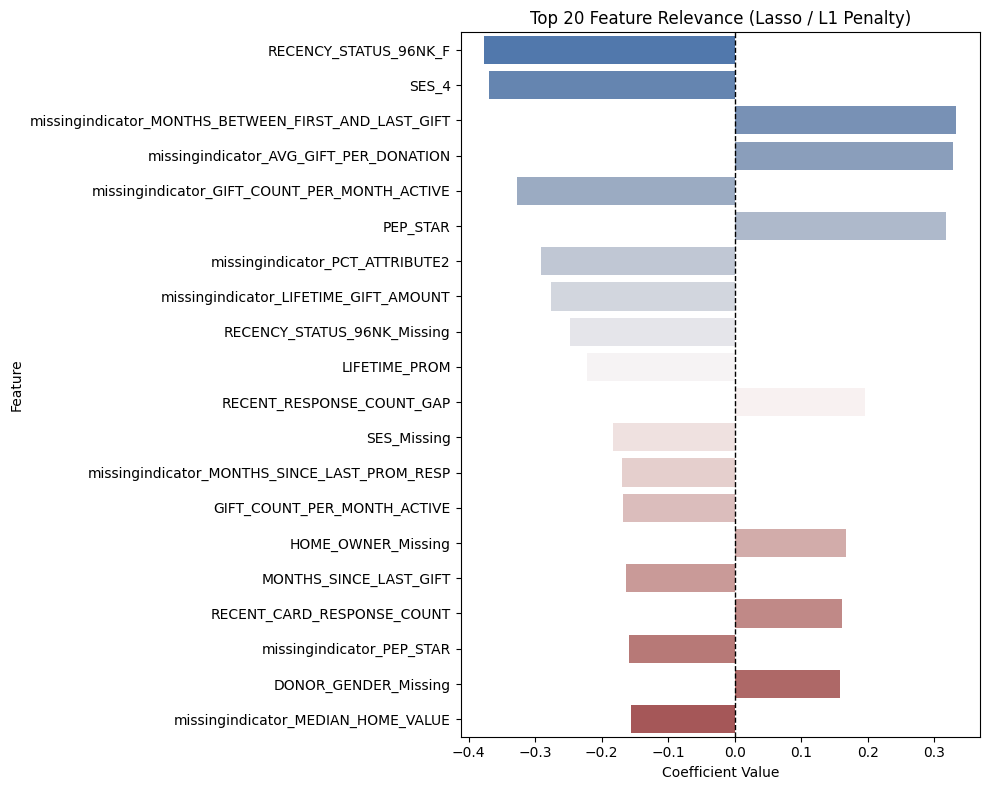

The Lasso model reduced 19 features to exactly 0.


In [17]:
"""3. Feature Relevance Visualization (Lasso Coefficient Importance)"""
lasso_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_model.coef_[0]
})


lasso_coefs['Abs_Coefficient'] = lasso_coefs['Coefficient'].abs()
top_features = lasso_coefs[lasso_coefs['Coefficient'] != 0].sort_values('Abs_Coefficient', ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x='Coefficient', y='Feature', palette='vlag')
plt.title("Top 20 Feature Relevance (Lasso / L1 Penalty)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print(f"The Lasso model reduced {sum(lasso_model.coef_[0] == 0)} features to exactly 0.")

Original dimensionality: 115 features
Dimensionality after PCA (95% variance): 31 components


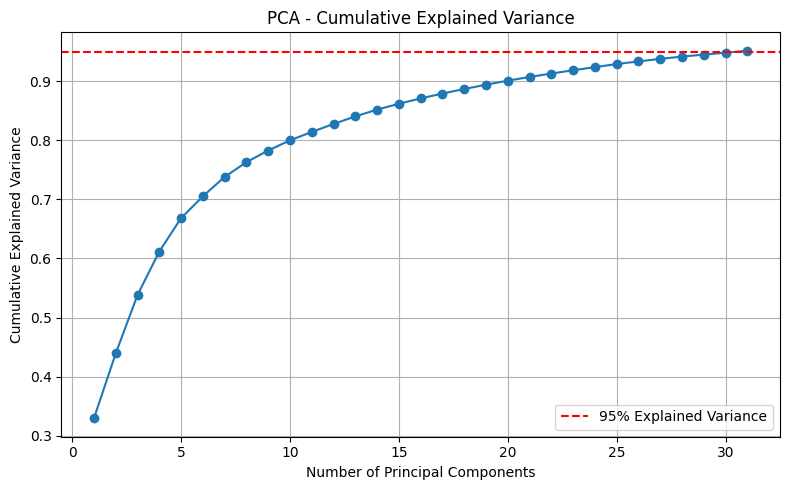

In [18]:
"""4. PCA (Principal Component Analysis)"""
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_prep)

print(f"Original dimensionality: {X_train_prep.shape[1]} features")
print(f"Dimensionality after PCA (95% variance): {X_train_pca.shape[1]} components")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 
         marker='o', linestyle='-')
plt.title('PCA - Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## <h3 style="border-bottom: 4px solid #b79ad6; margin: 0 0 25px 0; padding-bottom:6px; font-weight:bold; font-size:1.7em;text-align:left;">9. Exporting the final train and test datasets</h3>


In [ ]:
X_train_clean.to_csv(PROJECT_ROOT / "project_data" / "X_train_clean.csv", index=False)
X_val_clean.to_csv(PROJECT_ROOT / "project_data" / "X_val_clean.csv", index=False)
